In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet('../data/phh_prod_image_data_oasis_with_dmso.parquet')
df = pd.DataFrame(df)

In [8]:
print(df.shape)
print(df.columns)

(24576, 28)
Index(['well_id', 'brightfield', 'compound_id', 'plate', 'source', 'library',
       'compound_concentration_um', 'compound_pathway', 'compound_target',
       'compound_biological_activity', 'ldh_ridge_norm', 'mtt_ridge_norm',
       'bioactivity_svc_tvn_pca_platenorm_coral_regnorm_all_n_components_256',
       'mean_nuclei_count', 'mean_nuclei_count_ridge_norm',
       'mean_nuclei_count_ridge_norm_inv', 'mean_nuclei_area_mean',
       'mean_nuclei_area_mean_ridge_norm_inv', 'cyto_area_ratio',
       'cyto_area_ratio_ridge_norm', 'vacuole_sum', 'vacuole_ratio',
       'mito_puncta_ratio', 'mito_puncta_ratio_ridge_norm_sub',
       'ros_stress_granules_sum_mean_norm_ridge_norm_corr',
       'pca_embedding_raw', 'pca_embedding_normalized', 'batch'],
      dtype='str')


In [15]:
print("Plates: ",len(df['plate'].unique()))
print("Wells: ",len(df['well_id'].unique()))
print(df['well_id'][0:5])

Plates:  64
Wells:  24576
0     assayworks_prod_26_p=plate_41002887_r=12_c=4
1      assayworks_prod_30_p=plate_41002959_r=2_c=1
2     assayworks_prod_27_p=plate_41002893_r=6_c=17
3    assayworks_prod_25_p=plate_41002690_r=10_c=18
4    assayworks_prod_26_p=plate_41002883_r=14_c=10
Name: well_id, dtype: str


In [16]:
print(df['library'][0:5])

0    oasis
1       aw
2    oasis
3    oasis
4    oasis
Name: library, dtype: str


In [23]:
print("Oasis compound: ", len(df[df['library'] == 'oasis']))

oasis = df[df["library"] == "oasis"].copy()
oasis["conc"] = oasis["compound_concentration_um"].round(6)
# wells / doses / plates / batches per compound
per_compound = oasis.groupby("compound_id").agg(
    n_wells=("well_id", "nunique"),
    n_doses=("conc", "nunique"),
    n_plates=("plate", "nunique"),
    n_batches=("batch", "nunique"),
)
print(per_compound.value_counts())

# wells and plates per (compound, dose)
per_dose = oasis.groupby(["compound_id", "conc"]).agg(
    n_wells=("well_id", "nunique"),
    n_plates=("plate", "nunique"),
    n_batches=("batch", "nunique"),
)

print(per_dose.value_counts())
# wells of the same compound+dose on the same plate  -> should be 1
print(oasis.groupby(["compound_id", "conc", "plate"]).size().value_counts())

Oasis compound:  17408
n_wells  n_doses  n_plates  n_batches
16       8        16        2            1088
Name: count, dtype: int64
n_wells  n_plates  n_batches
2        2         2            8704
Name: count, dtype: int64
1    17408
Name: count, dtype: int64


In [35]:
comp = df.dropna(subset=["compound_id"]).drop_duplicates("compound_id")

print("Number of compounds with biological activity annotations: ", comp["compound_biological_activity"].notna().sum())

print("Unique targets: ", comp["compound_target"].nunique())
print("Unique pathways: ", comp["compound_pathway"].nunique())

print("Unique sources: ", df["source"].nunique())
print("Unique batches: ", df["batch"].nunique())
print(pd.crosstab(df["source"], df["batch"]))

Number of compounds with biological activity annotations:  1048
Unique targets:  551
Unique pathways:  232
Unique sources:  4
Unique batches:  4
batch                 25    26    27    30
source                                    
assayworks_prod_25  6144     0     0     0
assayworks_prod_26     0  6144     0     0
assayworks_prod_27     0     0  6144     0
assayworks_prod_30     0     0     0  6144


In [3]:
def split_labels(value):
    if pd.isna(value):
        return set()
    return {label.strip() for label in str(value).split(";") if label.strip()}

for column in ["compound_pathway", "compound_target"]:
    label_counts = (
        df.assign(labels=df[column].map(split_labels))
          .groupby("compound_id")["labels"]
          .agg(lambda rows: len(set().union(*rows)))
    )

    multiple = label_counts > 1
    print(
        f"{column}: {multiple.sum()} of {len(label_counts)} compounds "
        f"have multiple labels"
    )
    print("Label-count distribution:")
    print(label_counts.value_counts().sort_index())

compound_pathway: 562 of 1098 compounds have multiple labels
Label-count distribution:
labels
0     49
1    487
2    305
3    136
4     62
5     36
6     15
7      5
8      2
9      1
Name: count, dtype: int64
compound_target: 543 of 1098 compounds have multiple labels
Label-count distribution:
labels
0      49
1     506
2     281
3     109
4      79
5      39
6      20
7       5
8       4
9       3
10      3
Name: count, dtype: int64


In [4]:
for column in ["compound_pathway", "compound_target"]:
    counts = (
        df.assign(labels=df[column].map(split_labels))
          .groupby("compound_id")["labels"]
          .agg(lambda rows: len(set().union(*rows)))
    )

    print(f"{column}: {(counts > 3).sum()} compounds have more than 3 labels")

compound_pathway: 121 compounds have more than 3 labels
compound_target: 153 compounds have more than 3 labels


In [38]:
embedding_cols = ["brightfield", "pca_embedding_raw", "pca_embedding_normalized"]
for col in embedding_cols:
    M = np.stack(df[col].values).astype("float64")
    norms = np.linalg.norm(M, axis=1)
    coverage = pd.DataFrame({
        "source": df["source"].values,
        "norm": norms,
        "has_nan": np.isnan(M).any(axis=1),
        "all_zero": norms == 0,
    })
    print(f"\n{col}  dim={M.shape[1]}")
    print(coverage.groupby("source").agg(
        n_rows=("norm", "size"),
        n_all_zero=("all_zero", "sum"),
        n_with_nan=("has_nan", "sum"),
        mean_norm=("norm", "mean"),
    ))
# sources that have usable embeddings for every well
n_sources_with_features = sum(
    not np.isnan(np.stack(g["pca_embedding_raw"].values)).any()
    for _, g in df.groupby("source")
)
print("\nsources with complete image features:",
      n_sources_with_features, "of", df["source"].nunique())


brightfield  dim=768
                    n_rows  n_all_zero  n_with_nan  mean_norm
source                                                       
assayworks_prod_25    6144           0           0  22.059077
assayworks_prod_26    6144           0           0  22.068519
assayworks_prod_27    6144           0           0  22.102152
assayworks_prod_30    6144           0           0  22.211097

pca_embedding_raw  dim=256
                    n_rows  n_all_zero  n_with_nan  mean_norm
source                                                       
assayworks_prod_25    6144           0           0   7.102030
assayworks_prod_26    6144           0           0   6.126208
assayworks_prod_27    6144           0           0   6.584460
assayworks_prod_30    6144           0           0   5.739940

pca_embedding_normalized  dim=256
                    n_rows  n_all_zero  n_with_nan  mean_norm
source                                                       
assayworks_prod_25    6144           0         

In [6]:
feature_cols = [
    "compound_concentration_um",
    "ldh_ridge_norm",
    "mtt_ridge_norm",
    "bioactivity_svc_tvn_pca_platenorm_coral_regnorm_all_n_components_256",
    "mean_nuclei_count",
    "mean_nuclei_count_ridge_norm",
    "mean_nuclei_count_ridge_norm_inv",
    "mean_nuclei_area_mean",
    "mean_nuclei_area_mean_ridge_norm_inv",
    "cyto_area_ratio",
    "cyto_area_ratio_ridge_norm",
    "vacuole_sum",
    "vacuole_ratio",
    "mito_puncta_ratio",
    "mito_puncta_ratio_ridge_norm_sub",
    "ros_stress_granules_sum_mean_norm_ridge_norm_corr",
]

X = df[feature_cols].astype("float64")

spearman = X.corr(method="spearman")
pearson = X.corr(method="pearson")

pairs = pd.DataFrame(
    [
        {"a": a, "b": b, "spearman": spearman.loc[a, b], "pearson": pearson.loc[a, b]}
        for i, a in enumerate(feature_cols)
        for b in feature_cols[i + 1:]
    ]
).sort_values("spearman", ascending=False)

print("Most positively correlated")
print(pairs.head(12).to_string(index=False))
top12_correlated = pairs.head(12)
top12_correlated.to_csv("../results/exploratory/top12_correlated_features.csv", index = False)

print("\nMost anti-correlated")
print(pairs.tail(12).iloc[::-1].to_string(index=False))
top12_notcorrelated = pairs.tail(12).iloc[::-1]
top12_notcorrelated.to_csv("../results/exploratory/top12_notcorrelated_features.csv", index = False)

Most positively correlated
                                                                   a                                    b  spearman   pearson
                                                   mean_nuclei_count                      cyto_area_ratio  0.814693  0.868788
                                        mean_nuclei_count_ridge_norm           cyto_area_ratio_ridge_norm  0.753176  0.955093
                                                   mito_puncta_ratio     mito_puncta_ratio_ridge_norm_sub  0.721309  0.938569
                                                     cyto_area_ratio           cyto_area_ratio_ridge_norm  0.541575  0.937596
                                                   mean_nuclei_count         mean_nuclei_count_ridge_norm  0.528422  0.772856
                                                   mean_nuclei_count           cyto_area_ratio_ridge_norm  0.462766  0.754130
                                                         vacuole_sum                       

In [7]:
# Large rank-vs-linear gaps flag outlier-driven correlations,
# e.g. vacuole_sum ~ vacuole_ratio is +0.45 Spearman but -0.18 Pearson.
gap = (pairs["spearman"] - pairs["pearson"]).abs()
print(pairs.assign(gap=gap).nlargest(8, "gap").to_string(index=False))

                               a                                    b  spearman   pearson      gap
mean_nuclei_count_ridge_norm_inv mean_nuclei_area_mean_ridge_norm_inv  0.054843  0.836426 0.781584
    mean_nuclei_count_ridge_norm mean_nuclei_area_mean_ridge_norm_inv -0.054843 -0.836426 0.781584
mean_nuclei_count_ridge_norm_inv                mean_nuclei_area_mean -0.045908 -0.784104 0.738196
    mean_nuclei_count_ridge_norm                mean_nuclei_area_mean  0.045908  0.784104 0.738196
                  ldh_ridge_norm           cyto_area_ratio_ridge_norm -0.020950 -0.706929 0.685979
               mean_nuclei_count                mean_nuclei_area_mean -0.096564  0.563734 0.660298
                  ldh_ridge_norm         mean_nuclei_count_ridge_norm -0.037636 -0.695669 0.658033
                  ldh_ridge_norm     mean_nuclei_count_ridge_norm_inv  0.037636  0.695669 0.658033


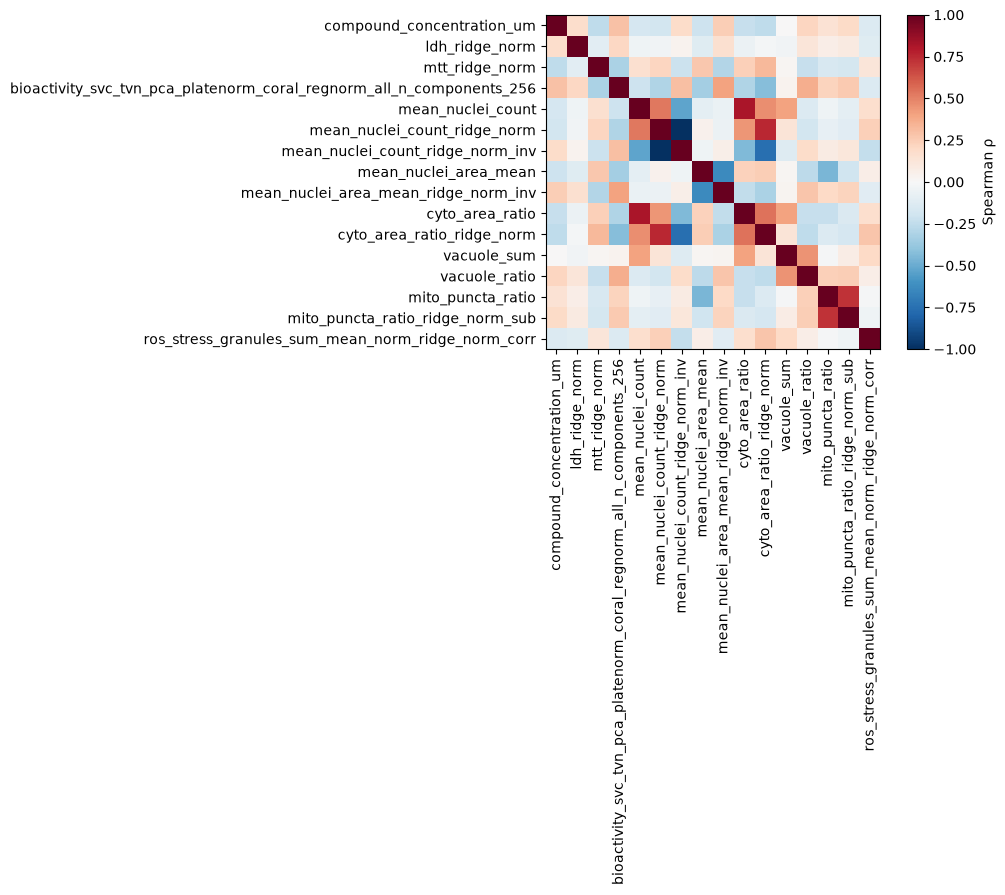

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(spearman, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90)
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels(feature_cols)
fig.colorbar(im, label="Spearman ρ")
fig.tight_layout()